Вариант №7

Импортируем библиотеки, укажем файл .csv и превратим его в датафрейм

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH_TO_FILE = 'student-mat.csv'

df = pd.read_csv(PATH_TO_FILE)

print(df)

Вывод:

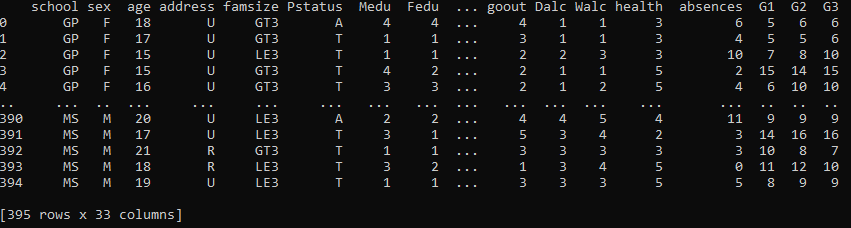

Информация о наборе

In [ ]:
print(df.info())

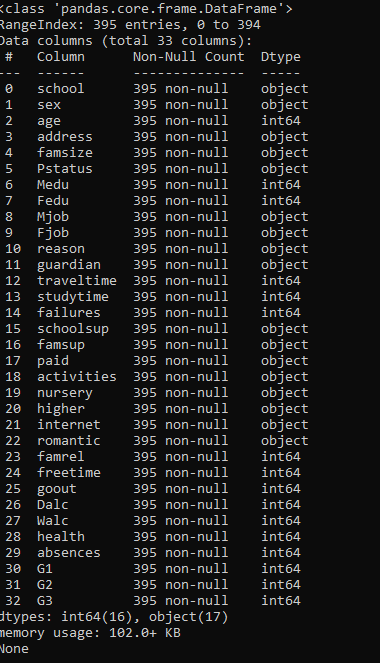

Статистический разбор по колонкам с числовым типом данных

In [ ]:
print(df.describe())

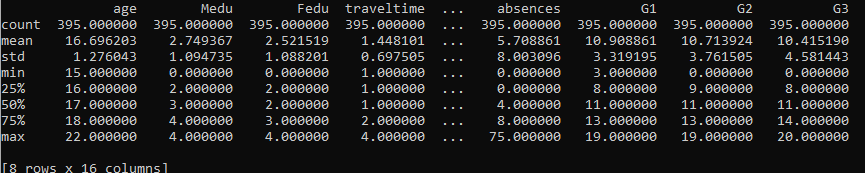

In [ ]:
Вывод колонок в наборе данных

In [ ]:
print(df.columns)

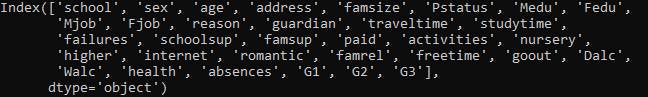

В данном наборе данных номинальными переменными являются school (школа), sex (пол), address (тип домашнего адреса), famsize (размер семьи), Pstatus (статус совместного проживания родителей), Mjob (работа матери), Fjob (работа отца), reason (причина выбора школы), guardian (опекун), schoolsup (дополнительная образовательная поддержка), famsup (семейная образовательная поддержка), paid (дополнительные платные занятия), activities (внеучебные занятия), nursery (посещение детского сада), higher (желание получить высшее образование), internet (доступ в интернет), romantic (наличие романтических отношений).

Порядковыми переменными являются Medu (образование матери), Fedu (образование отца), traveltime (время в пути от дома до школы), studytime (время, затрачиваемое на учебу в неделю), famrel (качество семейных отношений), freetime (свободное время после школы), goout (время, проведенное с друзьями), Dalc (потребление алкоголя в будние дни), Walc (потребление алкоголя в выходные дни), health (текущее состояние здоровья).

Числовыми переменными являются age (возраст), failures (количество неудач),absences (количество пропусков), G1 (оценка за первый период), G2 (оценка за второй период), G3 (итоговая оценка).

In [ ]:
nominal_variables = ["school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob", "reason", "guardian", "schoolsup", "famsup",  "paid",    "activities", "nursery", "higher", "internet", "romantic"]

for column in nominal_variables:
	print(f'{column}: {df[column].nunique()} уникальных значений')

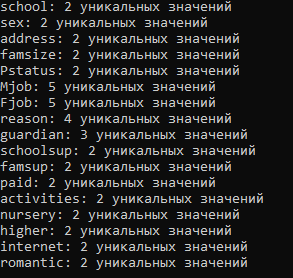

In [ ]:
ordinal_variables = ["Medu", "Fedu", "traveltime", "studytime", "famrel", "freetime", "goout", "Dalc", "Walc", "health"]

for column in ordinal_variables:
	print(f'{column}: {df[column].nunique()} уникальных значений')

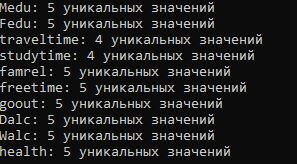

In [ ]:
numeric_variables = ["age", "failures", "absences", "G1", "G2", "G3"]

for column in numeric_variables:
	print(f'{column}: {df[column].nunique()} уникальных значений')

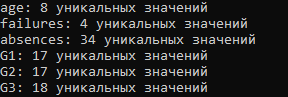

Выведем гистограмму для переменной absences, которая хранит количество пропусков в школе среди студентов:

In [ ]:
sns.histplot(df['absences'], kde=True)
plt.title('Распределение absences')
plt.xlabel('absences')
plt.ylabel('Частота')
plt.show()

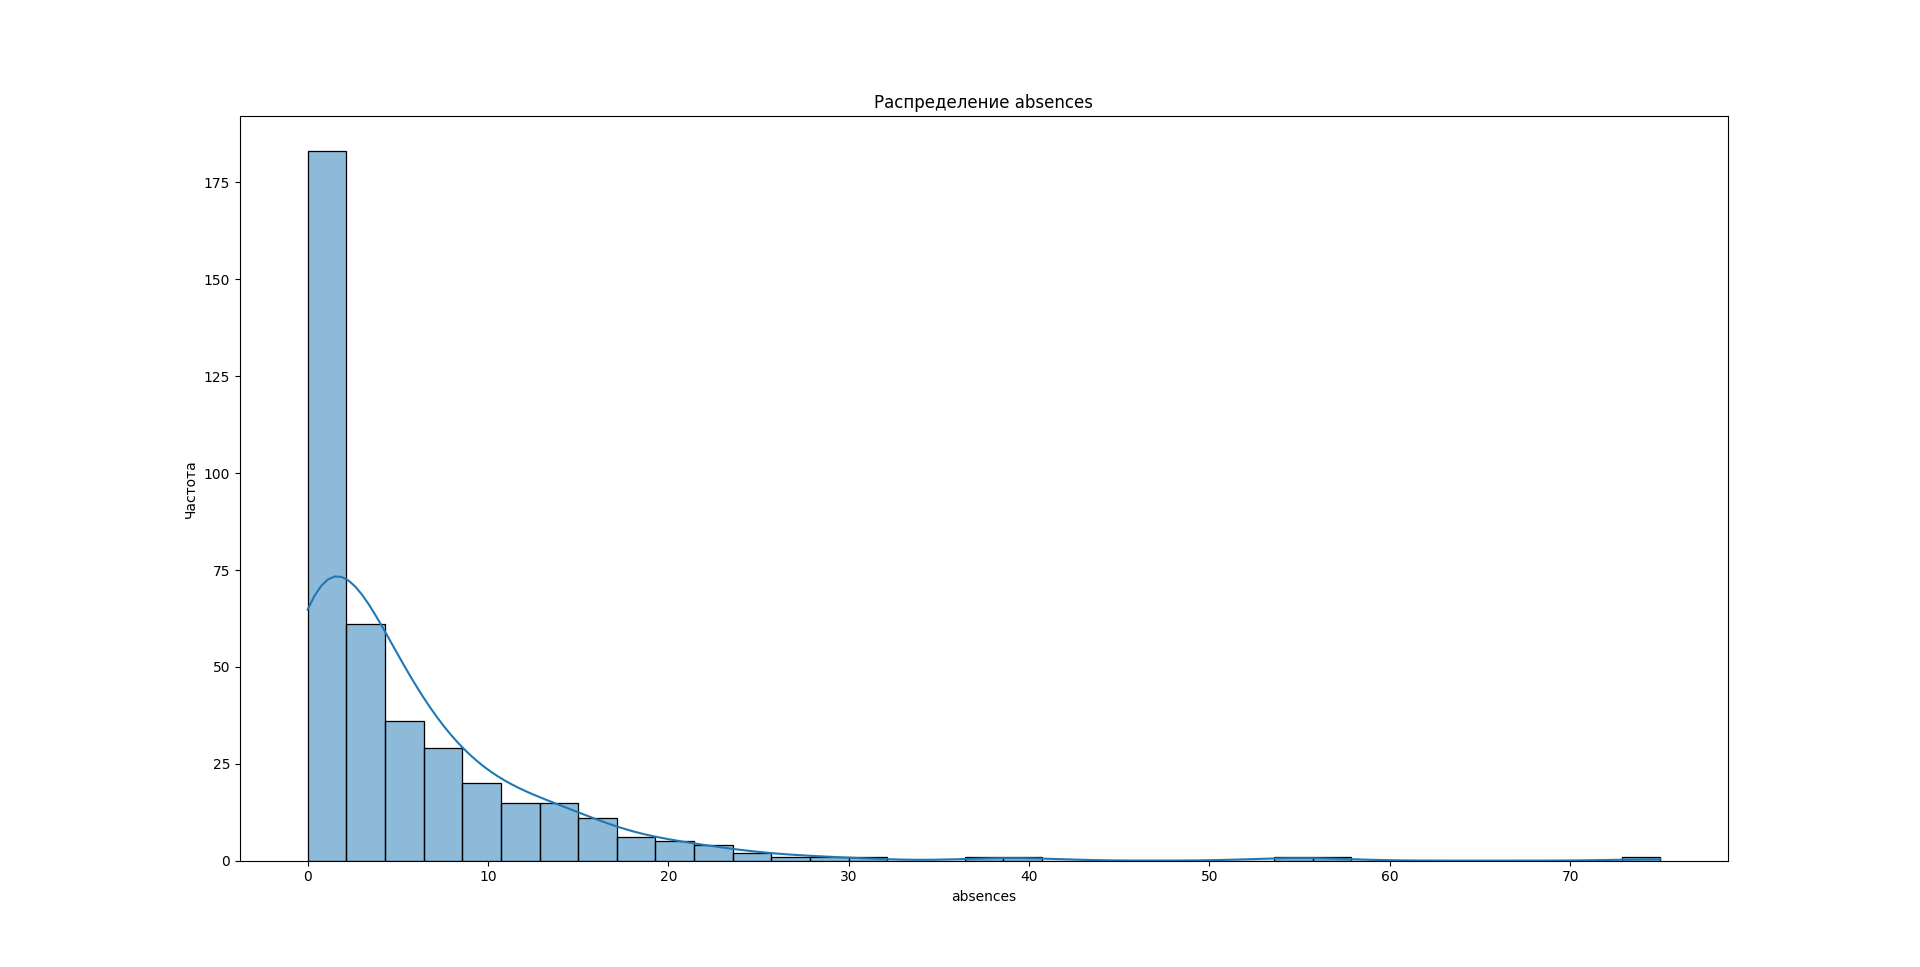

Данное распределение не является нормальным, потому что не имеет форму колокола и не является симметричным.
Концентрация большинства значений приходится на промежуток от 0 до 10.

Теперь выведем другие пять числовых переменных аналогичным образом:

In [ ]:
num_cols = df.columns.intersection(numeric_variables)

fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

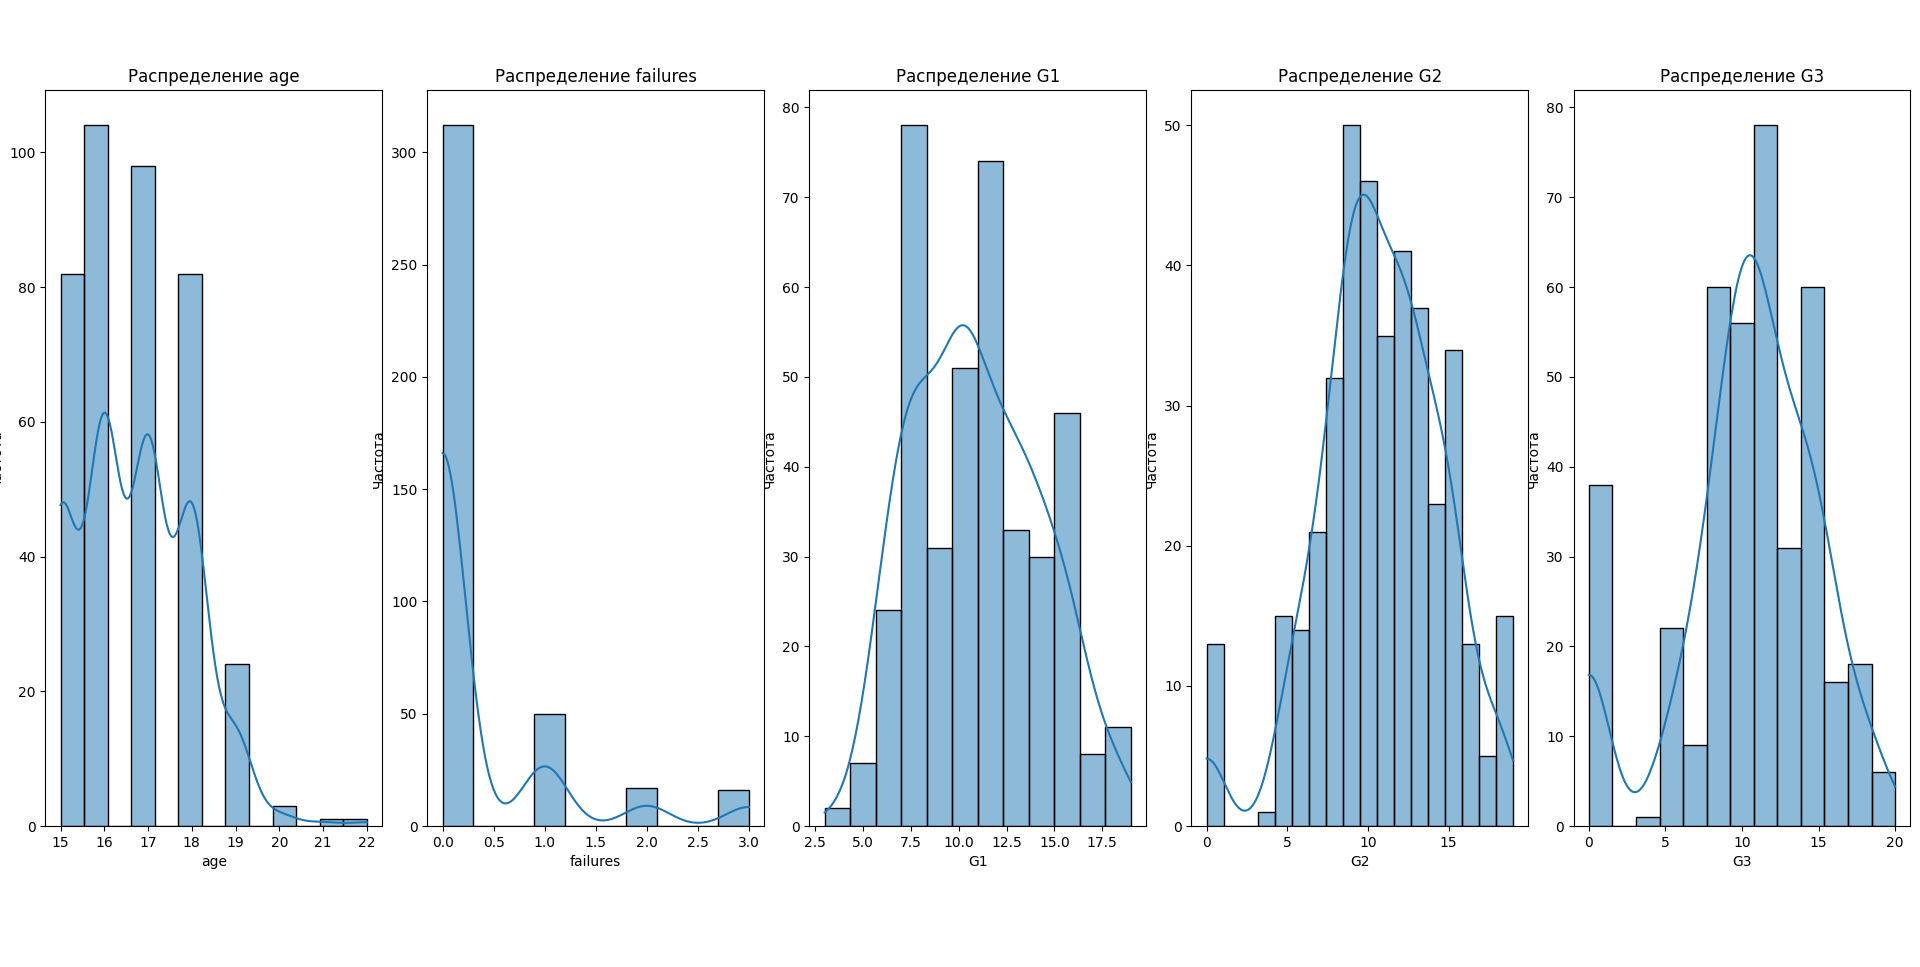

Из приведенных переменных ни одна не является нормально распределённой, потому что распределение не симметрично и есть много значений, которые значительно превышают остальные.

Выведем столбчатую диграмму по категориальной переменной health, которая показывает уровень здоровья студентов курса:

In [ ]:
sns.countplot(x='health', data=df)
plt.title('Распределение health')
plt.xlabel('health')
plt.ylabel('Количество')
plt.show()

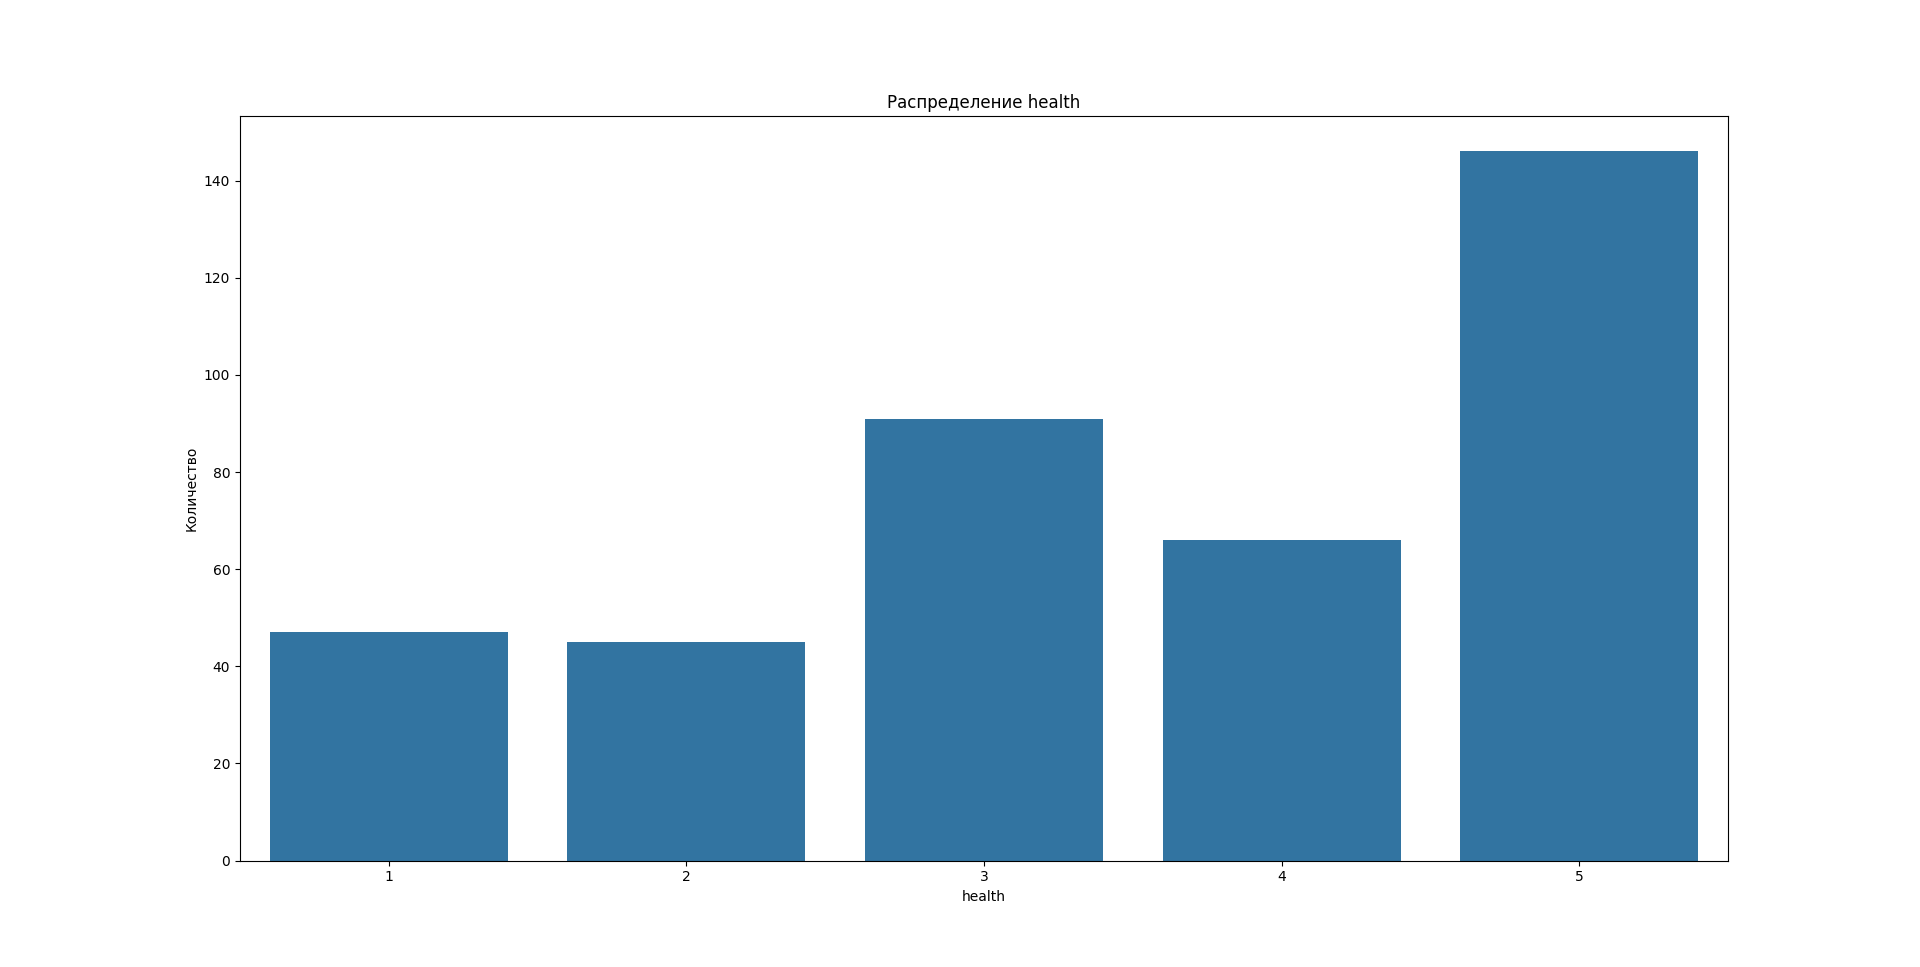

Значения концентрируются при health равном 3 и 5.

Выведем также гистограммы для 4-х других переменных:

In [ ]:
num_cols = df.columns.intersection(['Medu', 'Fedu', 'Dalc', 'Walc'])
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

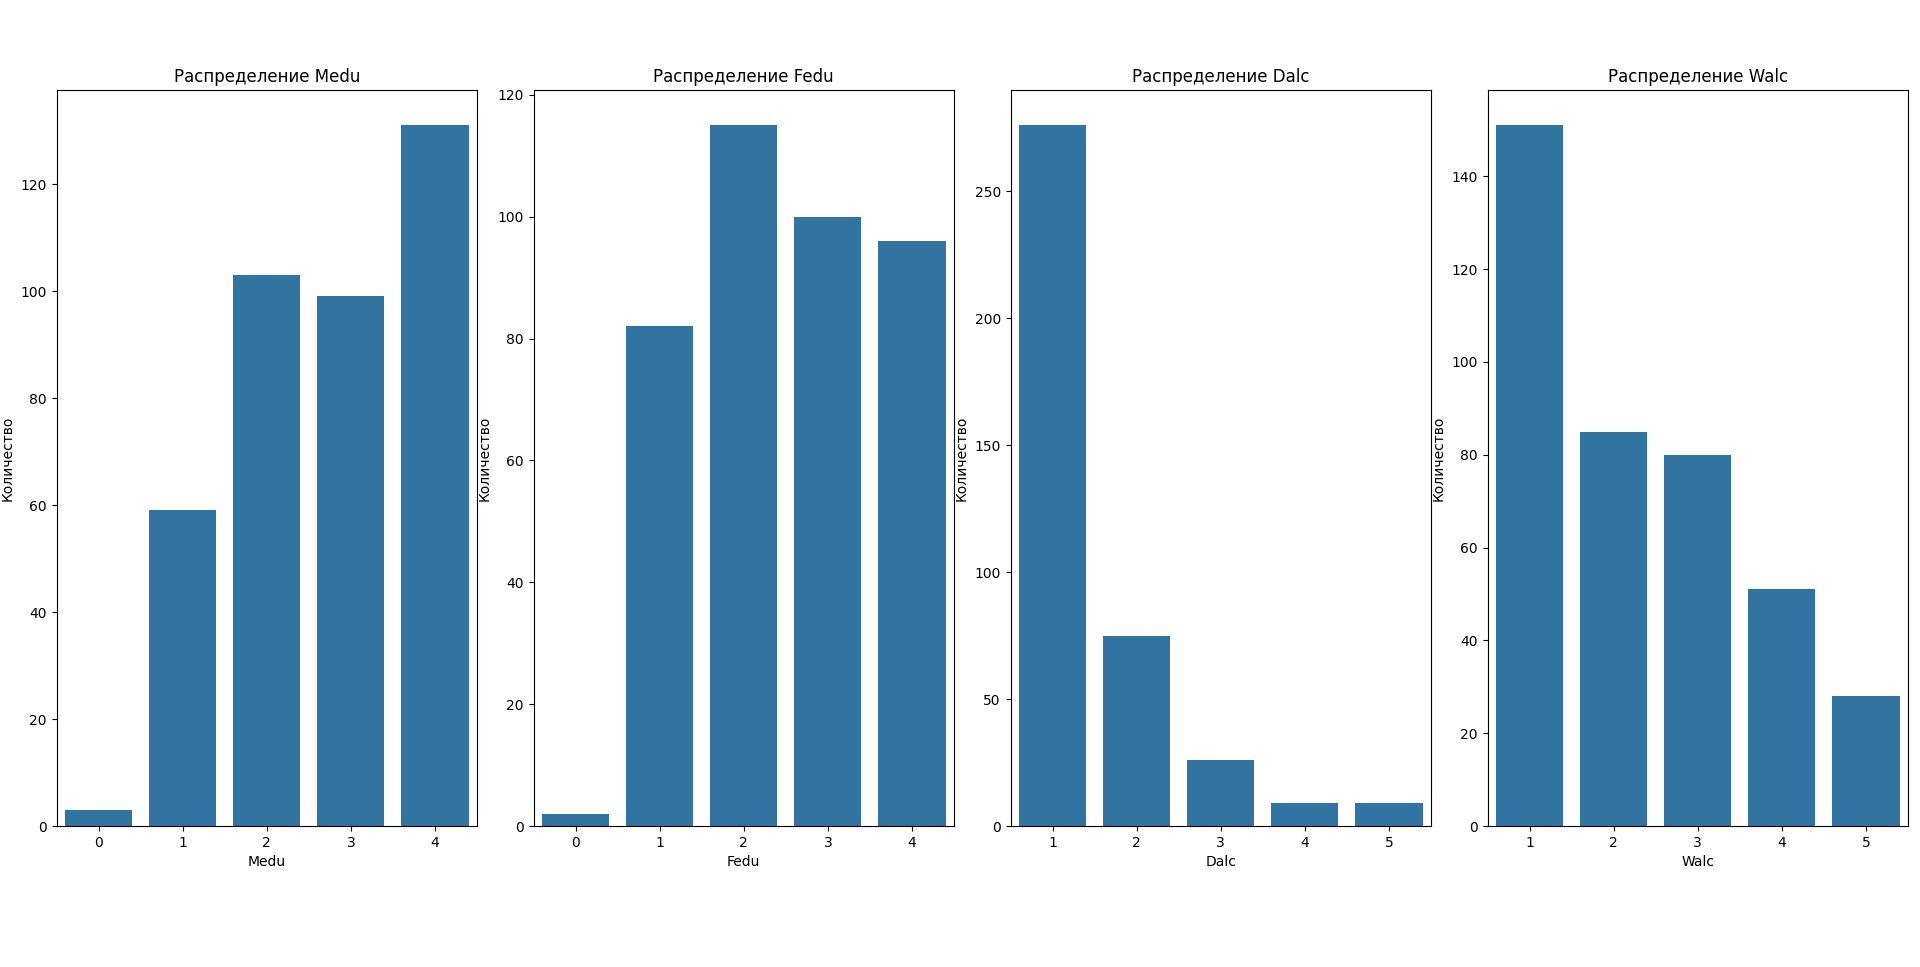

Выведем боксплот для переменной age, которая показывает возраст студентов:

In [ ]:
sns.boxplot(x=df['age'])
plt.title('Boxplot age')
plt.xlabel('age')
plt.show()

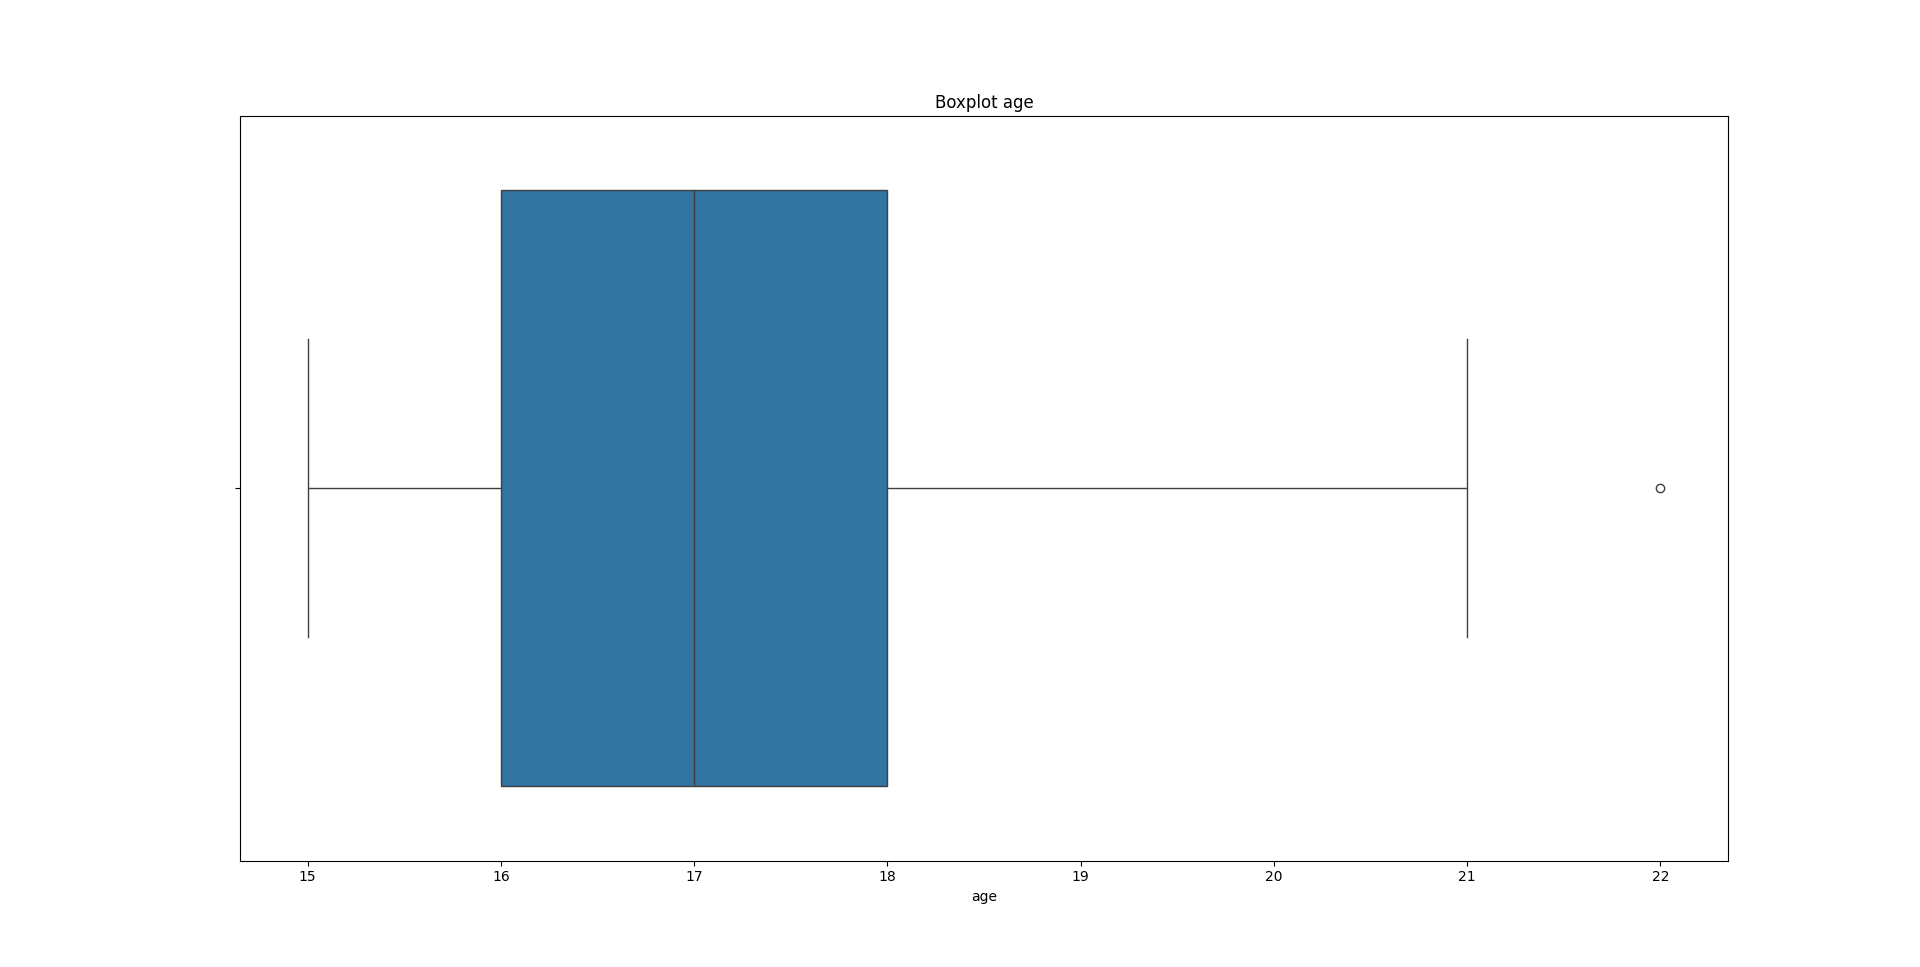

На графике можно увидеть выброс при значении равном 22

Построим корреляционную матрицу для всех числовых переменных и визуализируем её с помощью тепловой карты:

In [ ]:
correlation_matrix = df[numeric_variables].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

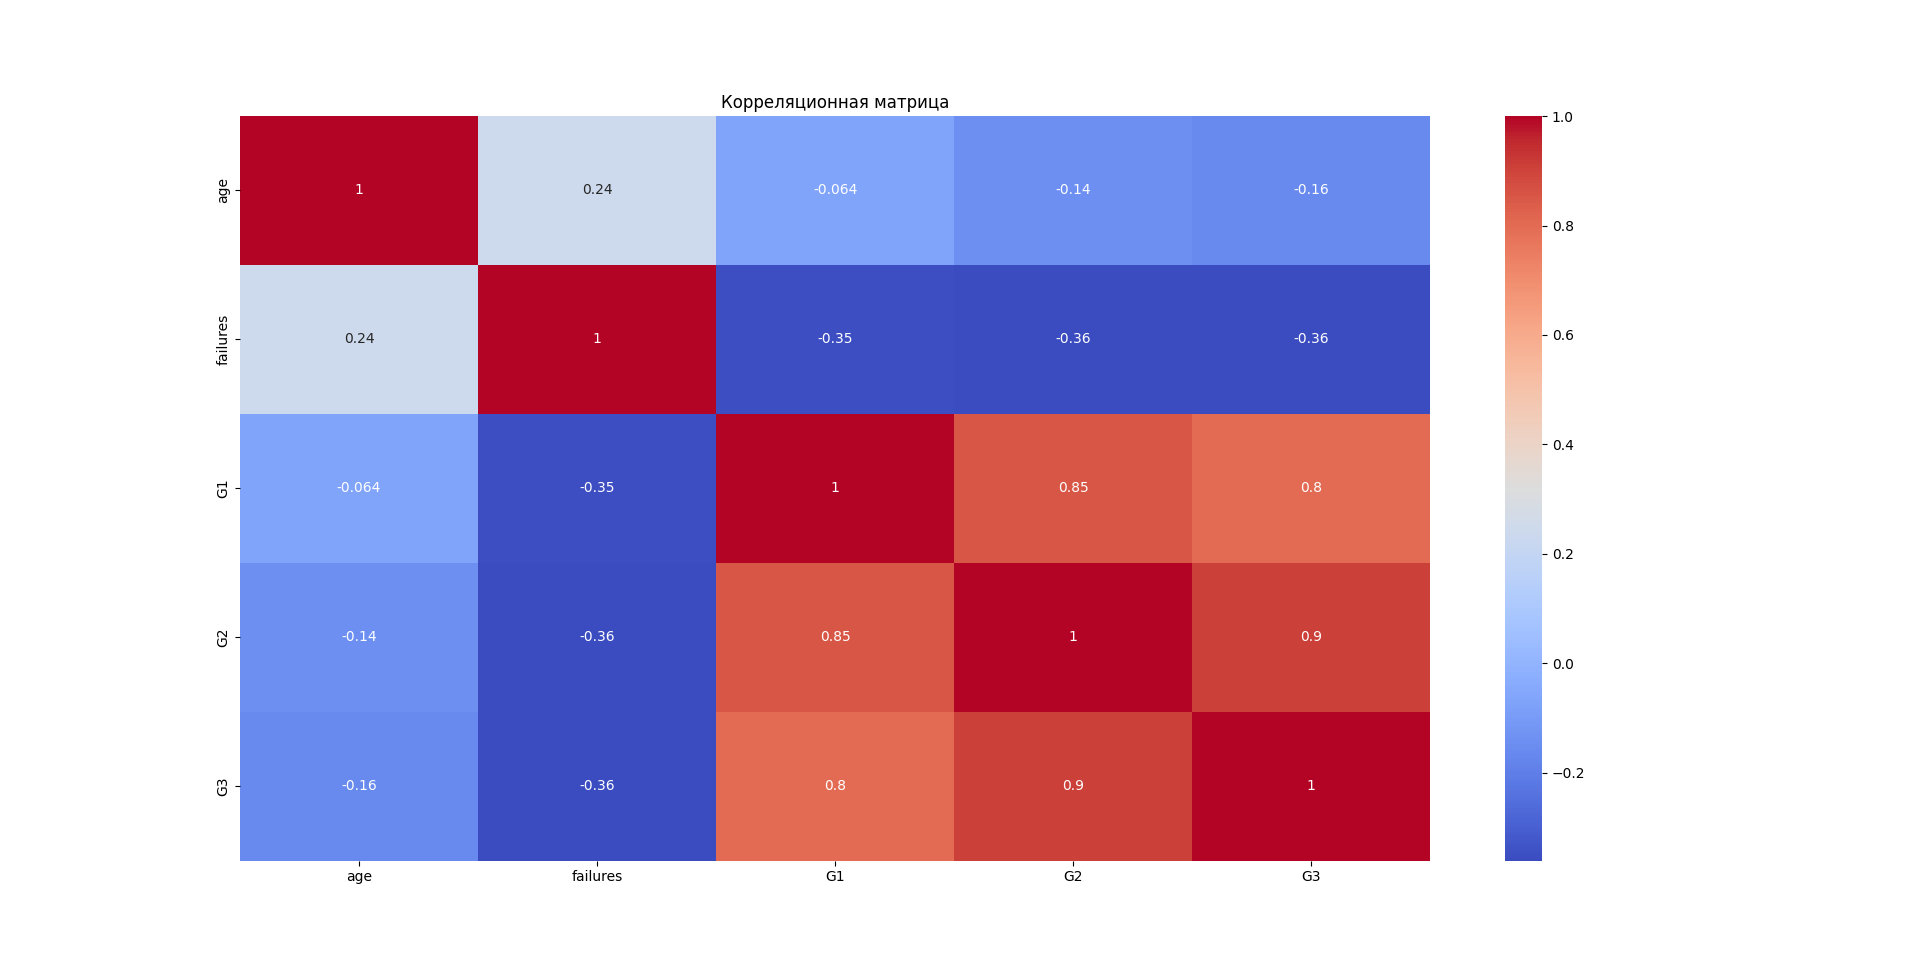

Практически не коррелируют пары переменных такие как age/G1, age/G2, age/G3, age/failures. Слабую отрицательную корреляцию имеют failures/G1, failures/G2, failures/G3. Сильную положительную корреляцию имеют G1/G2, G1/G3, G2/G3.